# Análisis de Producción de Alimento (Planta)

Este módulo tiene como objetivo procesar los datos históricos de fabricación de alimento para generar indicadores de gestión (BI) y preparar las variables para el modelo de Machine Learning.

## Objetivo: Cálculo de Alimento Creado Mensualmente
Se desarrolló este análisis para determinar el volumen total de alimento fabricado mes a mes. Esto permite a la gerencia visualizar la capacidad operativa de la planta y correlacionar estos picos de producción con el rendimiento posterior en la granja.

### Lógica de Cálculo:
1. **Normalización de Fechas:** Se transforma la columna `Efectiva` al formato `datetime` de Python.
2. **Periodización:** Se agrupan los registros por periodos mensuales (`YYYY-MM`).
3. **Agregación:** Se realiza la sumatoria de la columna `Cantidad` (kilos), la cual representa la mezcla final de todos los ingredientes procesados.

In [1]:
# Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Ruta del archivo
file_path = r'D:\crist\OneDrive\Estudios\Proyectos Para GitHub\avian-data-ml-pipeline\data\raw\AlimentoFabricado\ALIMENTOENERO2026.xls'

# Leer el archivo Excel
try:
    df = pd.read_excel(file_path, sheet_name='Datos')
    print("Archivo leído exitosamente.")
    df.info()  # Mostrar información del DataFrame
    display(df.head())  # Mostrar las primeras filas del DataFrame
except Exception as e:
    print(f"Error al leer el archivo: {e}")

Archivo leído exitosamente.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 33 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Fcha             5570 non-null   datetime64[ns]
 1   Efectiva         5570 non-null   datetime64[ns]
 2   Hora             5570 non-null   object        
 3   Núm tran         5570 non-null   int64         
 4   Program          5565 non-null   object        
 5   ID del Usuario   5570 non-null   object        
 6   Tipo Trans       5570 non-null   object        
 7   Orden            4678 non-null   object        
 8   Lín.             5570 non-null   int64         
 9   Observs          0 non-null      float64       
 10  Ventas/Trabajo   5 non-null      object        
 11  ID               5190 non-null   object        
 12  Dirección        63 non-null     object        
 13  Lín Producto     5570 non-null   int64         
 14  Numero artic

,Fcha,Efectiva,Hora,Núm tran,Program,ID del Usuario,Tipo Trans,Orden,Lín.,Observs,Ventas/Trabajo,ID,Dirección,Lín Producto,Numero articulo,Descripción,UM,Cnt Requerd,Cantidad,Prec,Moneda,PxQ,Monto Contable,CuMaterial,Lote/Serie,Referencia,Almacén,Ubicación,Peso Embarq,Peso Neto,CE180,Site Origen,Ubic Origen
0,2026-01-31,2026-01-31,12:50:00,28403130,iclotr02.p,rpalomin,RCT-TR,NaN,0,NaN,NaN,403129*,NaN,7,1325,Mycofix plus,kg,0.0,1000.0,4871.000000,CLP,4871000.0,4871000,4895.075595,LS-BI00002091,NaN,PIFCA,PIFCA,0,1,0.0,CINTA,TRANSITO
1,2026-01-31,2026-01-31,12:50:00,28403129,iclotr02.p,rpalomin,ISS-TR,NaN,0,NaN,NaN,403129*,NaN,7,1325,Mycofix plus,kg,0.0,-1000.0,4871.000000,CLP,-4871000.0,4871000,4871.000000,LS-BI00002091,NaN,CINTA,TRANSITO,0,1,0.0,NaN,NaN
2,2026-01-31,2026-01-31,12:50:00,28403128,iclotr02.p,rpalomin,CST-ADJ,NaN,0,NaN,NaN,NaN,NaN,7,1325,Mycofix plus,kg,1000.0,0.0,0.000000,CLP,0.0,0,5203.168699,NaN,NaN,PIFCA,NaN,0,1,0.0,NaN,NaN
3,2026-01-31,2026-01-31,12:39:59,28403127,iclotr02.p,rpalomin,RCT-TR,NaN,0,NaN,NaN,403126*,NaN,15,PICHALMTO,Almto Pichidegua POSTURA,KG,0.0,3100.0,260.209032,CLP,806648.0,806648,266.406323,PICH5ACO,NaN,PICH5ACO,PIFCA,0,1,0.0,PIFCA,PIFCA
4,2026-01-31,2026-01-31,12:39:59,28403126,iclotr02.p,rpalomin,ISS-TR,NaN,0,NaN,NaN,403126*,NaN,15,PICHALMTO,Almto Pichidegua POSTURA,KG,0.0,-3100.0,260.209032,CLP,-806648.0,806648,260.209032,PICH5ACO,NaN,PIFCA,PIFCA,0,1,0.0,NaN,NaN


## Variables a utilizar
Se seleccionan solamente las variables más importantes para la investigación. 

In [3]:
# Variable de interés
columnas_interes = [
    'Efectiva',
    'Tipo Trans',
    'Lín Producto',
    'Numero articulo',
    'Descripción',
    'Cantidad',
    'Lote/Serie'
]

# Verificar si las columnas de interés existen en el DataFrame
for col in columnas_interes:
    if col not in df.columns:
        print(f"Advertencia: La columna '{col}' no se encuentra en el DataFrame.")
    else:
        print(f"La columna '{col}' está presente en el DataFrame.")
        
# Filtrar el DataFrame para obtener solo las columnas de interés
df_filtrado = df[columnas_interes].copy()

# Mostrar las primeras filas del DataFrame filtrado
display(df_filtrado.head())

La columna 'Efectiva' está presente en el DataFrame.
La columna 'Tipo Trans' está presente en el DataFrame.
La columna 'Lín Producto' está presente en el DataFrame.
La columna 'Numero articulo' está presente en el DataFrame.
La columna 'Descripción' está presente en el DataFrame.
La columna 'Cantidad' está presente en el DataFrame.
La columna 'Lote/Serie' está presente en el DataFrame.


,Efectiva,Tipo Trans,Lín Producto,Numero articulo,Descripción,Cantidad,Lote/Serie
0,2026-01-31,RCT-TR,7,1325,Mycofix plus,1000.0,LS-BI00002091
1,2026-01-31,ISS-TR,7,1325,Mycofix plus,-1000.0,LS-BI00002091
2,2026-01-31,CST-ADJ,7,1325,Mycofix plus,0.0,NaN
3,2026-01-31,RCT-TR,15,PICHALMTO,Almto Pichidegua POSTURA,3100.0,PICH5ACO
4,2026-01-31,ISS-TR,15,PICHALMTO,Almto Pichidegua POSTURA,-3100.0,PICH5ACO


## Filtros para obtener la producción de alimento

### Tipo de transacción: RCT-WO y linea de producto 15
Se utiliza este tipo de transacción debido a que es de creación.

In [4]:
# Definir el tipo de transacción que indica creación de alimento
transaccion_creacion = ['RCT-WO']
linea_producto_alimento = [15]

# Filtrar el DataFrame para obtener solo las filas donde el tipo de transacción es 'RCT-WO'
df_creacion = df_filtrado[df_filtrado['Tipo Trans'].isin(transaccion_creacion) & df_filtrado['Lín Producto'].isin(linea_producto_alimento)].copy()

# Mostrar las primeras filas del DataFrame filtrado por creación de alimento
display(df_creacion.head())

,Efectiva,Tipo Trans,Lín Producto,Numero articulo,Descripción,Cantidad,Lote/Serie
6,2026-01-31,RCT-WO,15,PICHALMTO,Almto Pichidegua POSTURA,3100.0,PICH5ACO
27,2026-01-31,RCT-WO,15,PICHALMTO,Almto Pichidegua POSTURA,3100.0,PICH1B
47,2026-01-31,RCT-WO,15,PICHALMTO,Almto Pichidegua POSTURA,6130.0,PICH1A
69,2026-01-31,RCT-WO,15,PICHALMTO,Almto Pichidegua POSTURA,6050.0,PICH5D
90,2026-01-31,RCT-WO,15,PICHALMTO,Almto Pichidegua POSTURA,6100.0,PICH5B


In [5]:
# mostrar datos unicos de las columnas de tipo transaccion y linea producto
print("Tipos de Transacción únicos:")
print(df_creacion['Tipo Trans'].unique())
print("\nLíneas de Producto únicas:")
print(df_creacion['Lín Producto'].unique())

Tipos de Transacción únicos:
['RCT-WO']

Líneas de Producto únicas:
[15]


## Suma la cantidad de alimento creado

In [6]:
# Mostrar los distintos números de articulos únicos en el DataFrame filtrado por creación de alimento 
print("Tipos de articulos únicos:")
print(df_creacion['Numero articulo'].unique())

Tipos de articulos únicos:
['PICHALMTO' 'PIPREP' 'PI INI 1' 'picria']


In [7]:
# Sumar las cantidades
produccion_mensual_aliemnto = df_creacion['Cantidad'].sum()
print(f"Cantidad total de alimento creado en el mes: {produccion_mensual_aliemnto}")

Cantidad total de alimento creado en el mes: 2279485.0


## Visualizaciones

### Visualización de cada lote

C:\Users\crist\AppData\Local\Temp\ipykernel_8904\4083925571.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


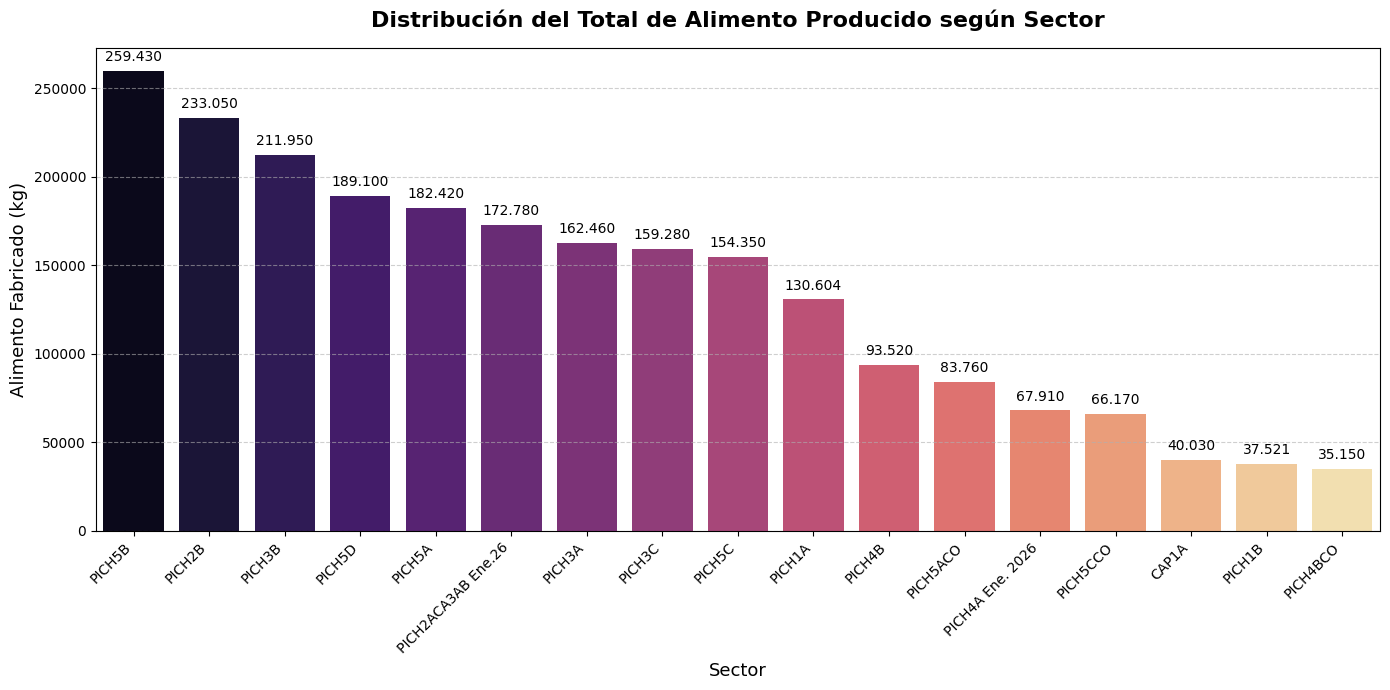

In [8]:

# 1. Agrupar por Lote y sumar la cantidad
# Nota: Si tu tabla se llama distinto, cambia 'df_creacion' por el nombre correcto de tu DataFrame
produccion_por_lote = df_creacion.groupby('Lote/Serie')['Cantidad'].sum().reset_index()

# 2. Ordenar de mayor a menor (Opcional pero muy recomendado para gráficos de barras)
produccion_por_lote = produccion_por_lote.sort_values(by='Cantidad', ascending=False)

# --- CREAR EL GRÁFICO ---
plt.figure(figsize=(14, 7)) # Un poco más ancho por si tienes muchos lotes

# Crear el gráfico de barras
ax = sns.barplot(
    data=produccion_por_lote, 
    x='Lote/Serie', 
    y='Cantidad', 
    palette='magma' # Una paleta de colores distinta para variar
)

# Añadir las etiquetas con los números exactos sobre cada barra
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}".replace(',', '.'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

# Darle formato a los textos y ejes
plt.title('Distribución del Total de Alimento Producido según Sector', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Sector', fontsize=13)
plt.ylabel('Alimento Fabricado (kg)', fontsize=13)

# Rotar los nombres de los lotes 45 grados por si son códigos muy largos y chocan entre sí
plt.xticks(rotation=45, ha='right') 

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Filtros para obtener el consumo de Insumos Base

### Tipo de transacción: ISS-WO y linea de producto 9
Se utiliza este tipo de transacción debido a que es de consumo y linea 9 para igredientes mayoritarios

In [10]:
# Definir el tipo de transacción que indica creación de alimento
transaccion_consumo_mayoritario = ['ISS-WO']
linea_producto_alimento = [9]

# Filtrar el DataFrame para obtener solo las filas donde el tipo de transacción es 'RCT-WO'
df_creacion_consumo_mayoritario = df_filtrado[df_filtrado['Tipo Trans'].isin(transaccion_consumo_mayoritario) & df_filtrado['Lín Producto'].isin(linea_producto_alimento)].copy()

# Convertir la columna 'Cantidad' a valores absolutos (positivos)
df_creacion_consumo_mayoritario['Cantidad'] = df_creacion_consumo_mayoritario['Cantidad'].abs()

# Mostrar las primeras filas del DataFrame filtrado por creación de alimento
display(df_creacion_consumo_mayoritario.head())

,Efectiva,Tipo Trans,Lín Producto,Numero articulo,Descripción,Cantidad,Lote/Serie
16,2026-01-31,ISS-WO,9,1033,Maíz molido 2017,1375.201333,NaN
17,2026-01-31,ISS-WO,9,1022,Soya 47 molida,508.751333,NaN
18,2026-01-31,ISS-WO,9,1020,Trigo molido,310.000000,NaN
19,2026-01-31,ISS-WO,9,1013,Poroto de Soya molida,63.942667,NaN
20,2026-01-31,ISS-WO,9,1005,Harina de Carne,48.256667,NaN


In [11]:
# mostrar datos unicos de las columnas de tipo transaccion y linea producto
print("Tipos de Transacción únicos:")
print(df_creacion_consumo_mayoritario['Tipo Trans'].unique())
print("\nLíneas de Producto únicas:")
print(df_creacion_consumo_mayoritario['Lín Producto'].unique())

Tipos de Transacción únicos:
['ISS-WO']

Líneas de Producto únicas:
[9]


## Visualización por cada insumo

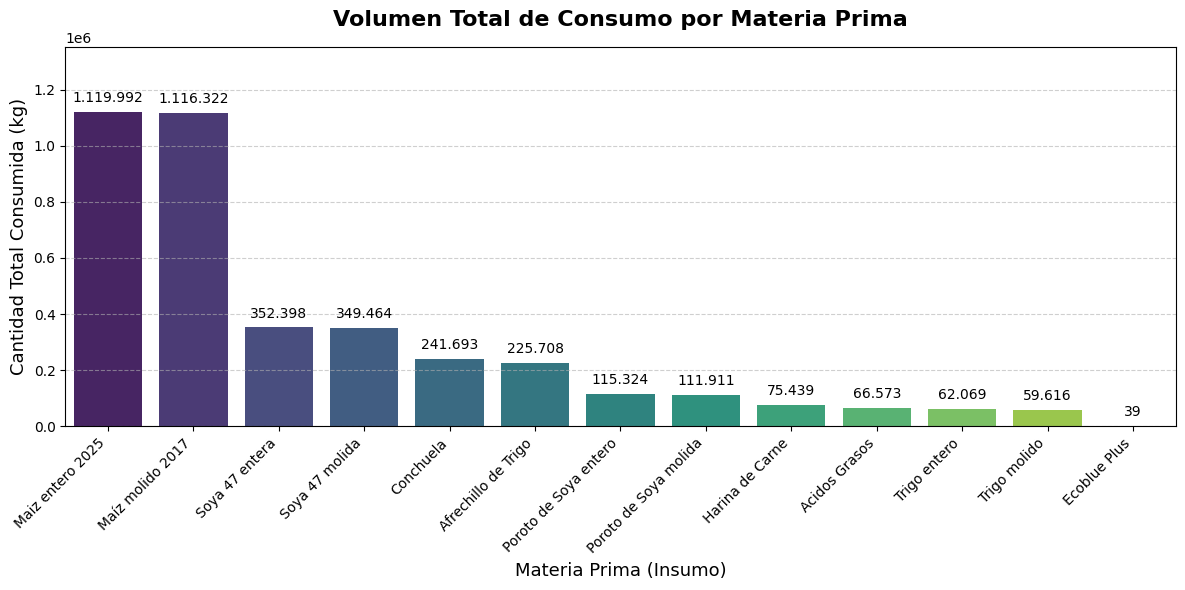

In [15]:
# 1. Agrupar por la descripción del insumo y sumar la cantidad consumida
# Asumiendo que tu tabla actual con las transacciones ISS-WO en positivo se llama df_filtrado
consumo_insumos = df_creacion_consumo_mayoritario.groupby('Descripción')['Cantidad'].sum().reset_index()

# 2. Ordenar de mayor a menor consumo
consumo_insumos = consumo_insumos.sort_values(by='Cantidad', ascending=False)

# --- CREAR EL GRÁFICO ---
plt.figure(figsize=(12, 6))

# Crear el gráfico de barras
ax = sns.barplot(
    data=consumo_insumos, 
    x='Descripción', 
    y='Cantidad', 
    hue='Descripción',
    palette='viridis', # Nueva paleta de colores para diferenciar de los Lotes
    legend=False
)
# Toma el límite actual del eje Y y lo multiplica por 1.15 (le da un 15% de espacio extra arriba)
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Añadir las etiquetas con los números exactos sobre cada barra
for p in ax.patches:
    # Evitar anotar barras con valor 0 o nulo para que no se vea feo
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height()):,}".replace(',', '.'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 5), 
                    textcoords='offset points')

# Darle formato a los textos y ejes
plt.title('Volumen Total de Consumo por Materia Prima', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Materia Prima (Insumo)', fontsize=13)
plt.ylabel('Cantidad Total Consumida (kg)', fontsize=13)

# Rotar los nombres de los insumos por si son muy largos
plt.xticks(rotation=45, ha='right') 

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Mostrar el gráfico (o st.pyplot(fig) si lo pasas a Streamlit directamente)
plt.show()